In [1]:
import tensorflow as tf

# Tensor Manipulations & Reshaping
## Task: Tensor Reshaping & Operations
1.	Create a random tensor of shape (4, 6).
2.	Find its rank and shape using TensorFlow functions.
3.	Reshape it into (2, 3, 4) and transpose it to (3, 2, 4).
4.	Broadcast a smaller tensor (1, 4) to match the larger tensor and add them.
5.	Explain how broadcasting works in TensorFlow.


In [5]:
# Create a random tensor of shape (4, 6)
tensor = tf.random.uniform(shape=(4,6))
print("Original Tensor:\n", tensor)

Original Tensor:
 tf.Tensor(
[[0.57159424 0.38526094 0.63844204 0.48648858 0.2805127  0.34358442]
 [0.6397159  0.04986143 0.9143076  0.41562963 0.93474734 0.51506853]
 [0.7714989  0.76561415 0.45645285 0.1638695  0.4237945  0.771911  ]
 [0.36637628 0.8075837  0.9203923  0.16641486 0.52842176 0.10437405]], shape=(4, 6), dtype=float32)


In [10]:
# Display the rank and shape of the tensor
print("Rank of the Tensor:", tf.rank(tensor))
print("Shape of the Tensor:", tf.shape(tensor))

Rank of the Tensor: tf.Tensor(2, shape=(), dtype=int32)
Shape of the Tensor: tf.Tensor([4 6], shape=(2,), dtype=int32)


In [18]:
# Reshaping the tensor to shape (2, 3, 4)
tensor = tf.reshape(tensor,(2,3,4))
print("Reshaped Tensor:\n", tensor)
print("Shape of the Reshaped Tensor:", tf.shape(tensor))
print("Rank of the Reshaped Tensor:", tf.rank(tensor))

Reshaped Tensor:
 tf.Tensor(
[[[0.57159424 0.38526094 0.63844204 0.48648858]
  [0.2805127  0.34358442 0.6397159  0.04986143]
  [0.9143076  0.41562963 0.93474734 0.51506853]]

 [[0.7714989  0.76561415 0.45645285 0.1638695 ]
  [0.4237945  0.771911   0.36637628 0.8075837 ]
  [0.9203923  0.16641486 0.52842176 0.10437405]]], shape=(2, 3, 4), dtype=float32)
Shape of the Reshaped Tensor: tf.Tensor([2 3 4], shape=(3,), dtype=int32)
Rank of the Reshaped Tensor: tf.Tensor(3, shape=(), dtype=int32)


In [19]:
# Transposing the tensor to shape (3, 2, 4)
transposed_tensor = tf.transpose(tensor, perm=[1, 0, 2])
print("Transposed Tensor:\n", transposed_tensor)
print("Shape of Transposed Tensor:", tf.shape(transposed_tensor))   
print("Rank of Transposed Tensor:", tf.rank(transposed_tensor))

Transposed Tensor:
 tf.Tensor(
[[[0.57159424 0.38526094 0.63844204 0.48648858]
  [0.7714989  0.76561415 0.45645285 0.1638695 ]]

 [[0.2805127  0.34358442 0.6397159  0.04986143]
  [0.4237945  0.771911   0.36637628 0.8075837 ]]

 [[0.9143076  0.41562963 0.93474734 0.51506853]
  [0.9203923  0.16641486 0.52842176 0.10437405]]], shape=(3, 2, 4), dtype=float32)
Shape of Transposed Tensor: tf.Tensor([3 2 4], shape=(3,), dtype=int32)
Rank of Transposed Tensor: tf.Tensor(3, shape=(), dtype=int32)


In [20]:
# Broadcasting a new tensor of shape (1, 4) to the large tensor and add them 

new_tensor = tf.random.uniform(shape=(1,4))
print("New Tensor:\n", new_tensor)
print("Shape of New Tensor:", tf.shape(new_tensor))
print("Rank of New Tensor:", tf.rank(new_tensor))

# Add the new tensor to the large tensor
result = tf.add(transposed_tensor, new_tensor)
print("Result of Addition:\n", result)

New Tensor:
 tf.Tensor([[0.42413044 0.7725425  0.5398009  0.36850274]], shape=(1, 4), dtype=float32)
Shape of New Tensor: tf.Tensor([1 4], shape=(2,), dtype=int32)
Rank of New Tensor: tf.Tensor(2, shape=(), dtype=int32)
Result of Addition:
 tf.Tensor(
[[[0.9957247  1.1578034  1.1782429  0.8549913 ]
  [1.1956294  1.5381566  0.9962537  0.53237224]]

 [[0.70464313 1.1161269  1.1795168  0.41836417]
  [0.84792495 1.5444535  0.90617716 1.1760864 ]]

 [[1.338438   1.1881721  1.4745482  0.88357127]
  [1.3445227  0.93895733 1.0682226  0.4728768 ]]], shape=(3, 2, 4), dtype=float32)


### Explanation of how broadcasting works in tensorflow

TensorFlow broadcasting allows tensors with different shapes to work together in operations such as addition, subtraction, or multiplication.

The rules for Tensorflow broadcasting are:

1. TensorFlow compares the dimensions from right to left.
2. If the dimensions are the same, they are compatible. For example, if both tensors have a dimension of four, TensorFlow can perform the operation normally.
3. If one of the dimensions is one, it can be expanded to match the other dimension. TensorFlow automatically repeats the values along that dimension when performing the calculation.
4. If one tensor has fewer dimensions, TensorFlow treats the missing dimensions at the beginning as having a size of one. This allows a smaller tensor to work with a larger tensor.
Broadcasting fails if two corresponding dimensions are different and neither of them is one. In that case, TensorFlow cannot determine how to match the tensors.


# Loss Functions & Hyperparameter Tuning 
## Task: Implement and Compare Loss Functions
1.	Define true values (y_true) and model predictions (y_pred).
2.	Compute Mean Squared Error (MSE) and Categorical Cross-Entropy (CCE) losses.
3.	Modify predictions slightly and check how loss values change.
4.	Plot loss function values using Matplotlib.

##### Expected Output:
 - Loss values printed for different predictions.
 - Bar chart comparing MSE and Cross-Entropy Loss.


In [21]:
import matplotlib.pyplot as plt


Matplotlib is building the font cache; this may take a moment.


In [22]:
# Define the true values and model predictions
y_true = tf.constant([
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1]
], dtype=tf.float32)

y_pred1 = tf.constant([
    [0.8, 0.1, 0.1],
    [0.1, 0.8, 0.1],
    [0.1, 0.2, 0.7]
], dtype=tf.float32)


In [23]:
# Define the loss functions
mse=tf.keras.losses.MeanSquaredError()
cel=tf.keras.losses.CategoricalCrossentropy()

In [29]:
# Calculate the loss values
mse_loss1 = mse(y_true, y_pred1)
cel_loss1 = cel(y_true, y_pred1)

print("Original Predictions")
print("MSE Loss:", mse_loss1.numpy())
print("CCE Loss:", cel_loss1.numpy())

Original Predictions
MSE Loss: 0.02888889
CCE Loss: 0.26765403


In [30]:
# Modify the predictions to be more accurate
y_pred2 = tf.constant([
    [0.9, 0.05, 0.05],
    [0.05, 0.9, 0.05],
    [0.05, 0.05, 0.9]
], dtype=tf.float32)

# Calculate the loss values for the improved predictions
mse_loss2 = mse(y_true, y_pred2)
cel_loss2 = cel(y_true, y_pred2)

print("Improved Predictions")
print("MSE Loss:", mse_loss2.numpy())
print("CCE Loss:", cel_loss2.numpy())

Improved Predictions
MSE Loss: 0.0050000013
CCE Loss: 0.10536054


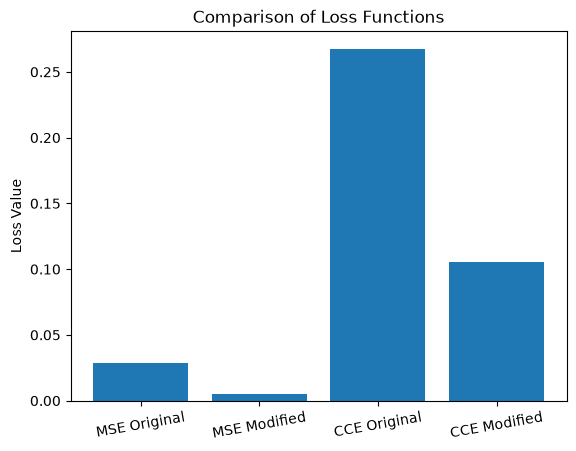

In [41]:
# Plot the loss values for both sets of predictions
labels = ["MSE Original", "MSE Modified",
          "CCE Original", "CCE Modified"]

loss_values = [
    mse_loss1,
    mse_loss2,
    cel_loss1,
    cel_loss2
]

plt.bar(labels, loss_values)

plt.title("Comparison of Loss Functions")
plt.ylabel("Loss Value")

plt.xticks(rotation=10)

plt.show()

# Train a Model with Different Optimizers
## Task: Train MNIST Model with Adam & SGD
1.	Load the MNIST dataset.
2.	Train two models: One with Adam and another with SGD.
3.	Compare training and validation accuracy trends.

Expected Output:
 - Accuracy plots comparing Adam vs. SGD performance.


In [43]:
# 1. Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test data shape:", x_test.shape)
print("Test labels shape:", y_test.shape)

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)


In [44]:
# Normalize the pixel values to be between 0 and 1
x_train = x_train / 255.0
x_test = x_test / 255.0

In [ ]:
# Define convolutional neural network
def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(28, 28, 1)),

        tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
        tf.keras.layers.MaxPooling2D((2, 2)),

        tf.keras.layers.Flatten(),

        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(10, activation="softmax")
    ])

    return model

In [53]:
# Training with Adam optimizer
adam_model = create_model()

adam_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Training with Adam...")

adam_history = adam_model.fit(
    x_train,
    y_train,
    epochs=20,
    validation_split=0.2
)

# Evaluate the model on the test set
adam_loss, adam_accuracy = adam_model.evaluate(x_test, y_test, verbose=0)
print("\nAdam Test Accuracy:", adam_accuracy)



Training with Adam...
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 532us/step - accuracy: 0.9207 - loss: 0.2812 - val_accuracy: 0.9546 - val_loss: 0.1523
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 529us/step - accuracy: 0.9636 - loss: 0.1247 - val_accuracy: 0.9653 - val_loss: 0.1155
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 510us/step - accuracy: 0.9740 - loss: 0.0869 - val_accuracy: 0.9688 - val_loss: 0.1045
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 519us/step - accuracy: 0.9802 - loss: 0.0662 - val_accuracy: 0.9683 - val_loss: 0.1056
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 548us/step - accuracy: 0.9855 - loss: 0.0496 - val_accuracy: 0.9712 - val_loss: 0.0961
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 519us/step - accuracy: 0.9886 - loss: 0.0388 - val_accuracy: 0.9749 - val_loss: 0.0887
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 546us/step - accuracy: 0.9911 - loss: 0.0303 - val_accuracy: 0.9751 - val_loss: 0.0895
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 551us/ste

In [54]:
# Training with SGD optimizer
sgd_model = create_model()

sgd_model.compile(
    optimizer="sgd",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nTraining with SGD...")

sgd_history = sgd_model.fit(
    x_train,
    y_train,
    epochs=20,
    validation_split=0.2
)

sgd_loss, sgd_accuracy = sgd_model.evaluate(x_test, y_test, verbose=0)

print("\nSGD Test Accuracy:", sgd_accuracy)


Training with SGD...
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 398us/step - accuracy: 0.8166 - loss: 0.7345 - val_accuracy: 0.8975 - val_loss: 0.3852
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 376us/step - accuracy: 0.8985 - loss: 0.3681 - val_accuracy: 0.9118 - val_loss: 0.3148
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 372us/step - accuracy: 0.9111 - loss: 0.3149 - val_accuracy: 0.9220 - val_loss: 0.2810
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 391us/step - accuracy: 0.9199 - loss: 0.2838 - val_accuracy: 0.9268 - val_loss: 0.2600
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 413us/step - accuracy: 0.9269 - loss: 0.2607 - val_accuracy: 0.9320 - val_loss: 0.2419
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 405us/step - accuracy: 0.9322 - loss: 0.2418 - val_accuracy: 0.9361 - val_loss: 0.2297
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 398us/step - accuracy: 0.9359 - loss: 0.2256 - val_accuracy: 0.9400 - val_loss: 0.2149
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 375us/ste

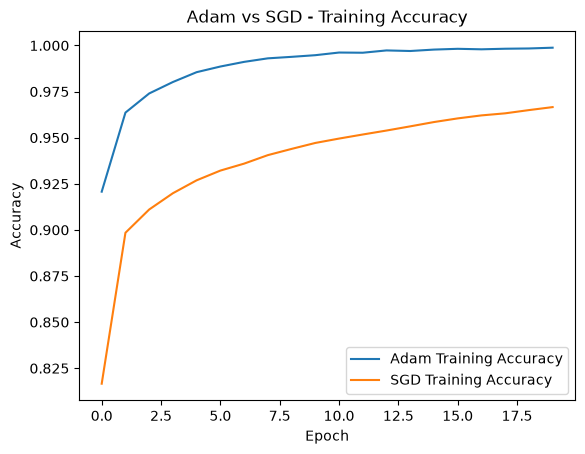

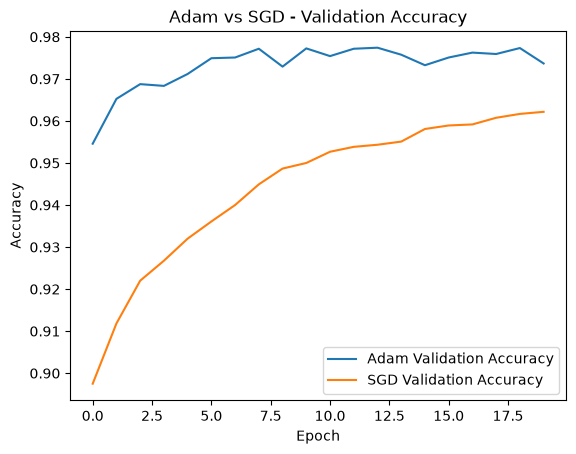

In [55]:
# Compare training accuracy
plt.plot(adam_history.history["accuracy"], label="Adam Training Accuracy")
plt.plot(sgd_history.history["accuracy"], label="SGD Training Accuracy")

plt.title("Adam vs SGD - Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


# Compare validation accuracy
plt.plot(adam_history.history["val_accuracy"], label="Adam Validation Accuracy")
plt.plot(sgd_history.history["val_accuracy"], label="SGD Validation Accuracy")

plt.title("Adam vs SGD - Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Train a Neural Network and Log to TensorBoard
## Task Description
1.	Load the MNIST dataset and preprocess it.
2.	Train a simple neural network model and enable TensorBoard logging.
3.	Launch TensorBoard and analyze loss and accuracy trends.
Expected Outcome:
- The model should train for 5 epochs and store logs in the "logs/fit/" directory.
- You should be able to visualize training vs. validation accuracy and loss in TensorBoard.


In [58]:
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

# Preprocess the data
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


In [59]:
# Define a simple neural network model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation="relu"),

    tf.keras.layers.Dense(10, activation="softmax")
])

In [60]:
# Create the log directory for TensorBoard

from datetime import datetime

log_dir = "logs/fit/" + datetime.now().strftime("%Y%m%d-%H%M%S")

tensorboard_callback = tf.keras.callbacks.TensorBoard(
    log_dir=log_dir
)

In [61]:
# Compile the model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [63]:
# Train the model for 5 epochs with TensorBoard callback
model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_split=0.2,
    callbacks=[tensorboard_callback]
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 613us/step - accuracy: 0.9182 - loss: 0.2857 - val_accuracy: 0.9544 - val_loss: 0.1592
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 579us/step - accuracy: 0.9627 - loss: 0.1283 - val_accuracy: 0.9644 - val_loss: 0.1200
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 572us/step - accuracy: 0.9732 - loss: 0.0890 - val_accuracy: 0.9694 - val_loss: 0.1001
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 573us/step - accuracy: 0.9805 - loss: 0.0645 - val_accuracy: 0.9732 - val_loss: 0.0891
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 589us/step - accuracy: 0.9847 - loss: 0.0507 - val_accuracy: 0.9695 - val_loss: 0.1011


In [64]:
# Evaluate on test data
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 269us/step - accuracy: 0.9726 - loss: 0.0905
Test Loss: 0.09047724306583405
Test Accuracy: 0.972599983215332


# 4.1 Questions to Answer:
1.	What patterns do you observe in the training and validation accuracy curves?
2.	How can you use TensorBoard to detect overfitting?
3.	What happens when you increase the number of epochs?
